# Test Trace, Corner, And FPD

Minimal notebook for reading one multimass HMC `.nc` file, plotting diagnostics, and computing `fpd_31`, `fpd_32`, `fpd_34`.

In [1]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys

import arviz as az
import corner
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.constrained_layout.use'] = True

if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))


In [3]:
input_suffix = '_ss=2_full_light_multimass'
cosmo_tag = 'desi_planck'  # or 'pantheonsh0es'
run_tag = '20260405_20'    # edit this
batch_idx = 0              # edit this

suffix_hmc = f"{input_suffix}_step6_{cosmo_tag}"
RUN_OUTPUT_DIR = Path('/mnt/lustre/tianli/quasar_hmc') / f'WFI2033{suffix_hmc}_{run_tag}'
NC_PATH = RUN_OUTPUT_DIR / f'WFI2033_{batch_idx}{suffix_hmc}.nc'

inf_data_pixel = az.from_netcdf(str(NC_PATH))
post = inf_data_pixel.posterior
num_chains = int(post.sizes['chain'])

print('NC_PATH =', NC_PATH)
print('posterior sizes =', dict(post.sizes))
print('data vars =', list(post.data_vars))


NC_PATH = /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_full_light_multimass_step6_desi_planck_20260405_20/WFI2033_0_ss=2_full_light_multimass_step6_desi_planck.nc
posterior sizes = {'chain': 6, 'draw': 1000, 'D_dt_model_Mpc_dim_0': 1, 'D_dt_true_Mpc_dim_0': 1, 'Lens mass g1 scalers - [1]': 1, 'Lens mass g2 scalers - [1]': 1, 'center_halo_dim_0': 2, 'cosmo_vec_dim_0': 2, 'dec_ps_dim_0': 4, 'dt_31_days_dim_0': 1, 'dt_32_days_dim_0': 1, 'dt_34_days_dim_0': 1, 'Lens mass vectors - [2]': 2, 'fermat_potential_images_dim_0': 4, 'log10_amp_ps_dim_0': 4, 'log_psf_corr_center_dim_0': 101, 'log_psf_corr_center_dim_1': 101, 'mass_from_light_amp_dim_0': 5, 'ml_gauss_dim_0': 5, 'model_image_dim_0': 150, 'model_image_dim_1': 150, 'Source grid power spectrum params - [1]': 1, 'pixels_source_grid_dim_0': 74, 'pixels_source_grid_dim_1': 74, 'Source grid fft x - [74]': 74, 'Source grid fft y - [74]': 74, 'psf_corr_factor_field_dim_0': 101, 'psf_corr_factor_field_dim_1': 101, 'psf_kernel_corrected_dim_0': 1

In [4]:
div = inf_data_pixel.sample_stats['diverging']
print('diverging dims =', div.dims)
print('diverging shape =', div.shape)

if div.dims == ('chain', 'draw', 'diverging_dim_0'):
    div_counts = np.asarray(div.sum(dim='draw').values, dtype=int)
    print('divergences per chain:')
    print(f'  block 0 (main lens/source/cosmo/AGN): {div_counts[:, 0]}')
    print(f'  block 1 (psf correction): {div_counts[:, 1]}')
else:
    print('divergences per chain:')
    print(np.asarray(div.sum(dim='draw').values, dtype=int))


diverging dims = ('chain', 'draw', 'diverging_dim_0')
diverging shape = (6, 1000, 2)
divergences per chain:
  block 0 (main lens/source/cosmo/AGN): [0 0 0 0 0 0]
  block 1 (psf correction): [0 0 0 0 0 0]


In [5]:
vars_mass = [
    'm2l_ratio', 'm2l_ratio_slope',
    'kappa_s_halo', 'gammain_halo', 'e_halo',
    'Rs_halo', 'center_halo', 'gamma_sheer_halo',
    'theta_E_g1', 'theta_E_g2', 'theta_E_g3', 'theta_E_g7',
]
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
vars_point_source = ['ra_ps', 'dec_ps', 'log10_amp_ps']
vars_cosmo = ['omega_m_cosmo', 'H0_cosmo', 'kappa_ext']
vars_delay = ['fpd_31', 'fpd_32', 'fpd_34', 'dt_31_days', 'dt_32_days', 'dt_34_days']

available_trace_vars = [
    name for name in (vars_mass + vars_power + vars_point_source + vars_cosmo + vars_delay)
    if name in post.data_vars
]

corner_vars_main = [
    name for name in (vars_mass + vars_cosmo)
    if name in post.data_vars
]

corner_vars_delay = [
    name for name in (vars_cosmo + vars_delay)
    if name in post.data_vars
]

print('trace vars =', available_trace_vars)
print('main corner vars =', corner_vars_main)
print('delay corner vars =', corner_vars_delay)


trace vars = ['m2l_ratio', 'm2l_ratio_slope', 'kappa_s_halo', 'gammain_halo', 'e_halo', 'Rs_halo', 'center_halo', 'gamma_sheer_halo', 'theta_E_g1', 'theta_E_g2', 'theta_E_g3', 'theta_E_g7', 'n_source_grid', 'rho_source_grid', 'sigma_source_grid', 'ra_ps', 'dec_ps', 'log10_amp_ps', 'omega_m_cosmo', 'H0_cosmo', 'kappa_ext', 'fpd_31', 'fpd_32', 'fpd_34', 'dt_31_days', 'dt_32_days', 'dt_34_days']
main corner vars = ['m2l_ratio', 'm2l_ratio_slope', 'kappa_s_halo', 'gammain_halo', 'e_halo', 'Rs_halo', 'center_halo', 'gamma_sheer_halo', 'theta_E_g1', 'theta_E_g2', 'theta_E_g3', 'theta_E_g7', 'omega_m_cosmo', 'H0_cosmo', 'kappa_ext']
delay corner vars = ['omega_m_cosmo', 'H0_cosmo', 'kappa_ext', 'fpd_31', 'fpd_32', 'fpd_34', 'dt_31_days', 'dt_32_days', 'dt_34_days']


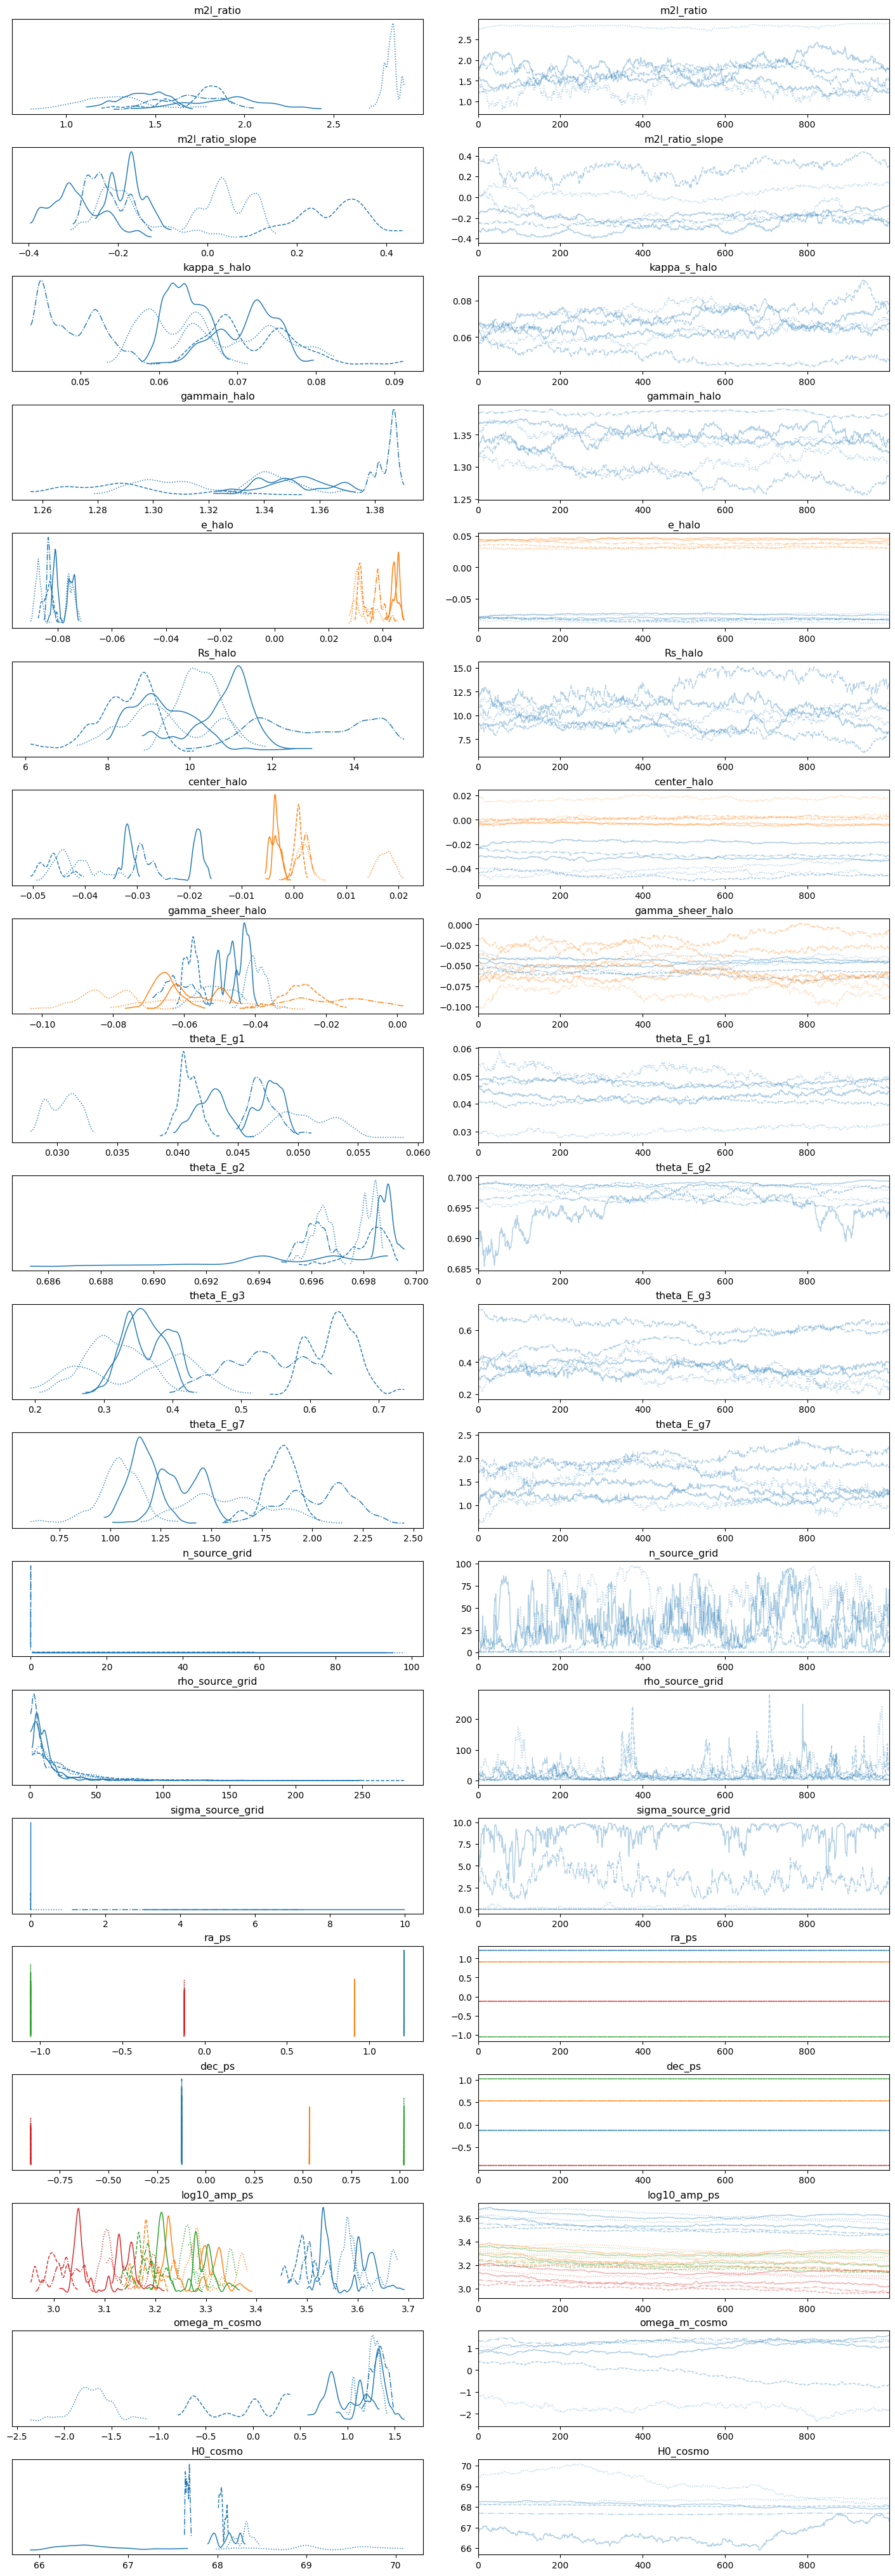

In [6]:
_ = az.plot_trace(
    inf_data_pixel,
    var_names=available_trace_vars,
    figsize=(14, max(8, 1.5 * len(available_trace_vars))),
    divergences=True,
)
plt.show()


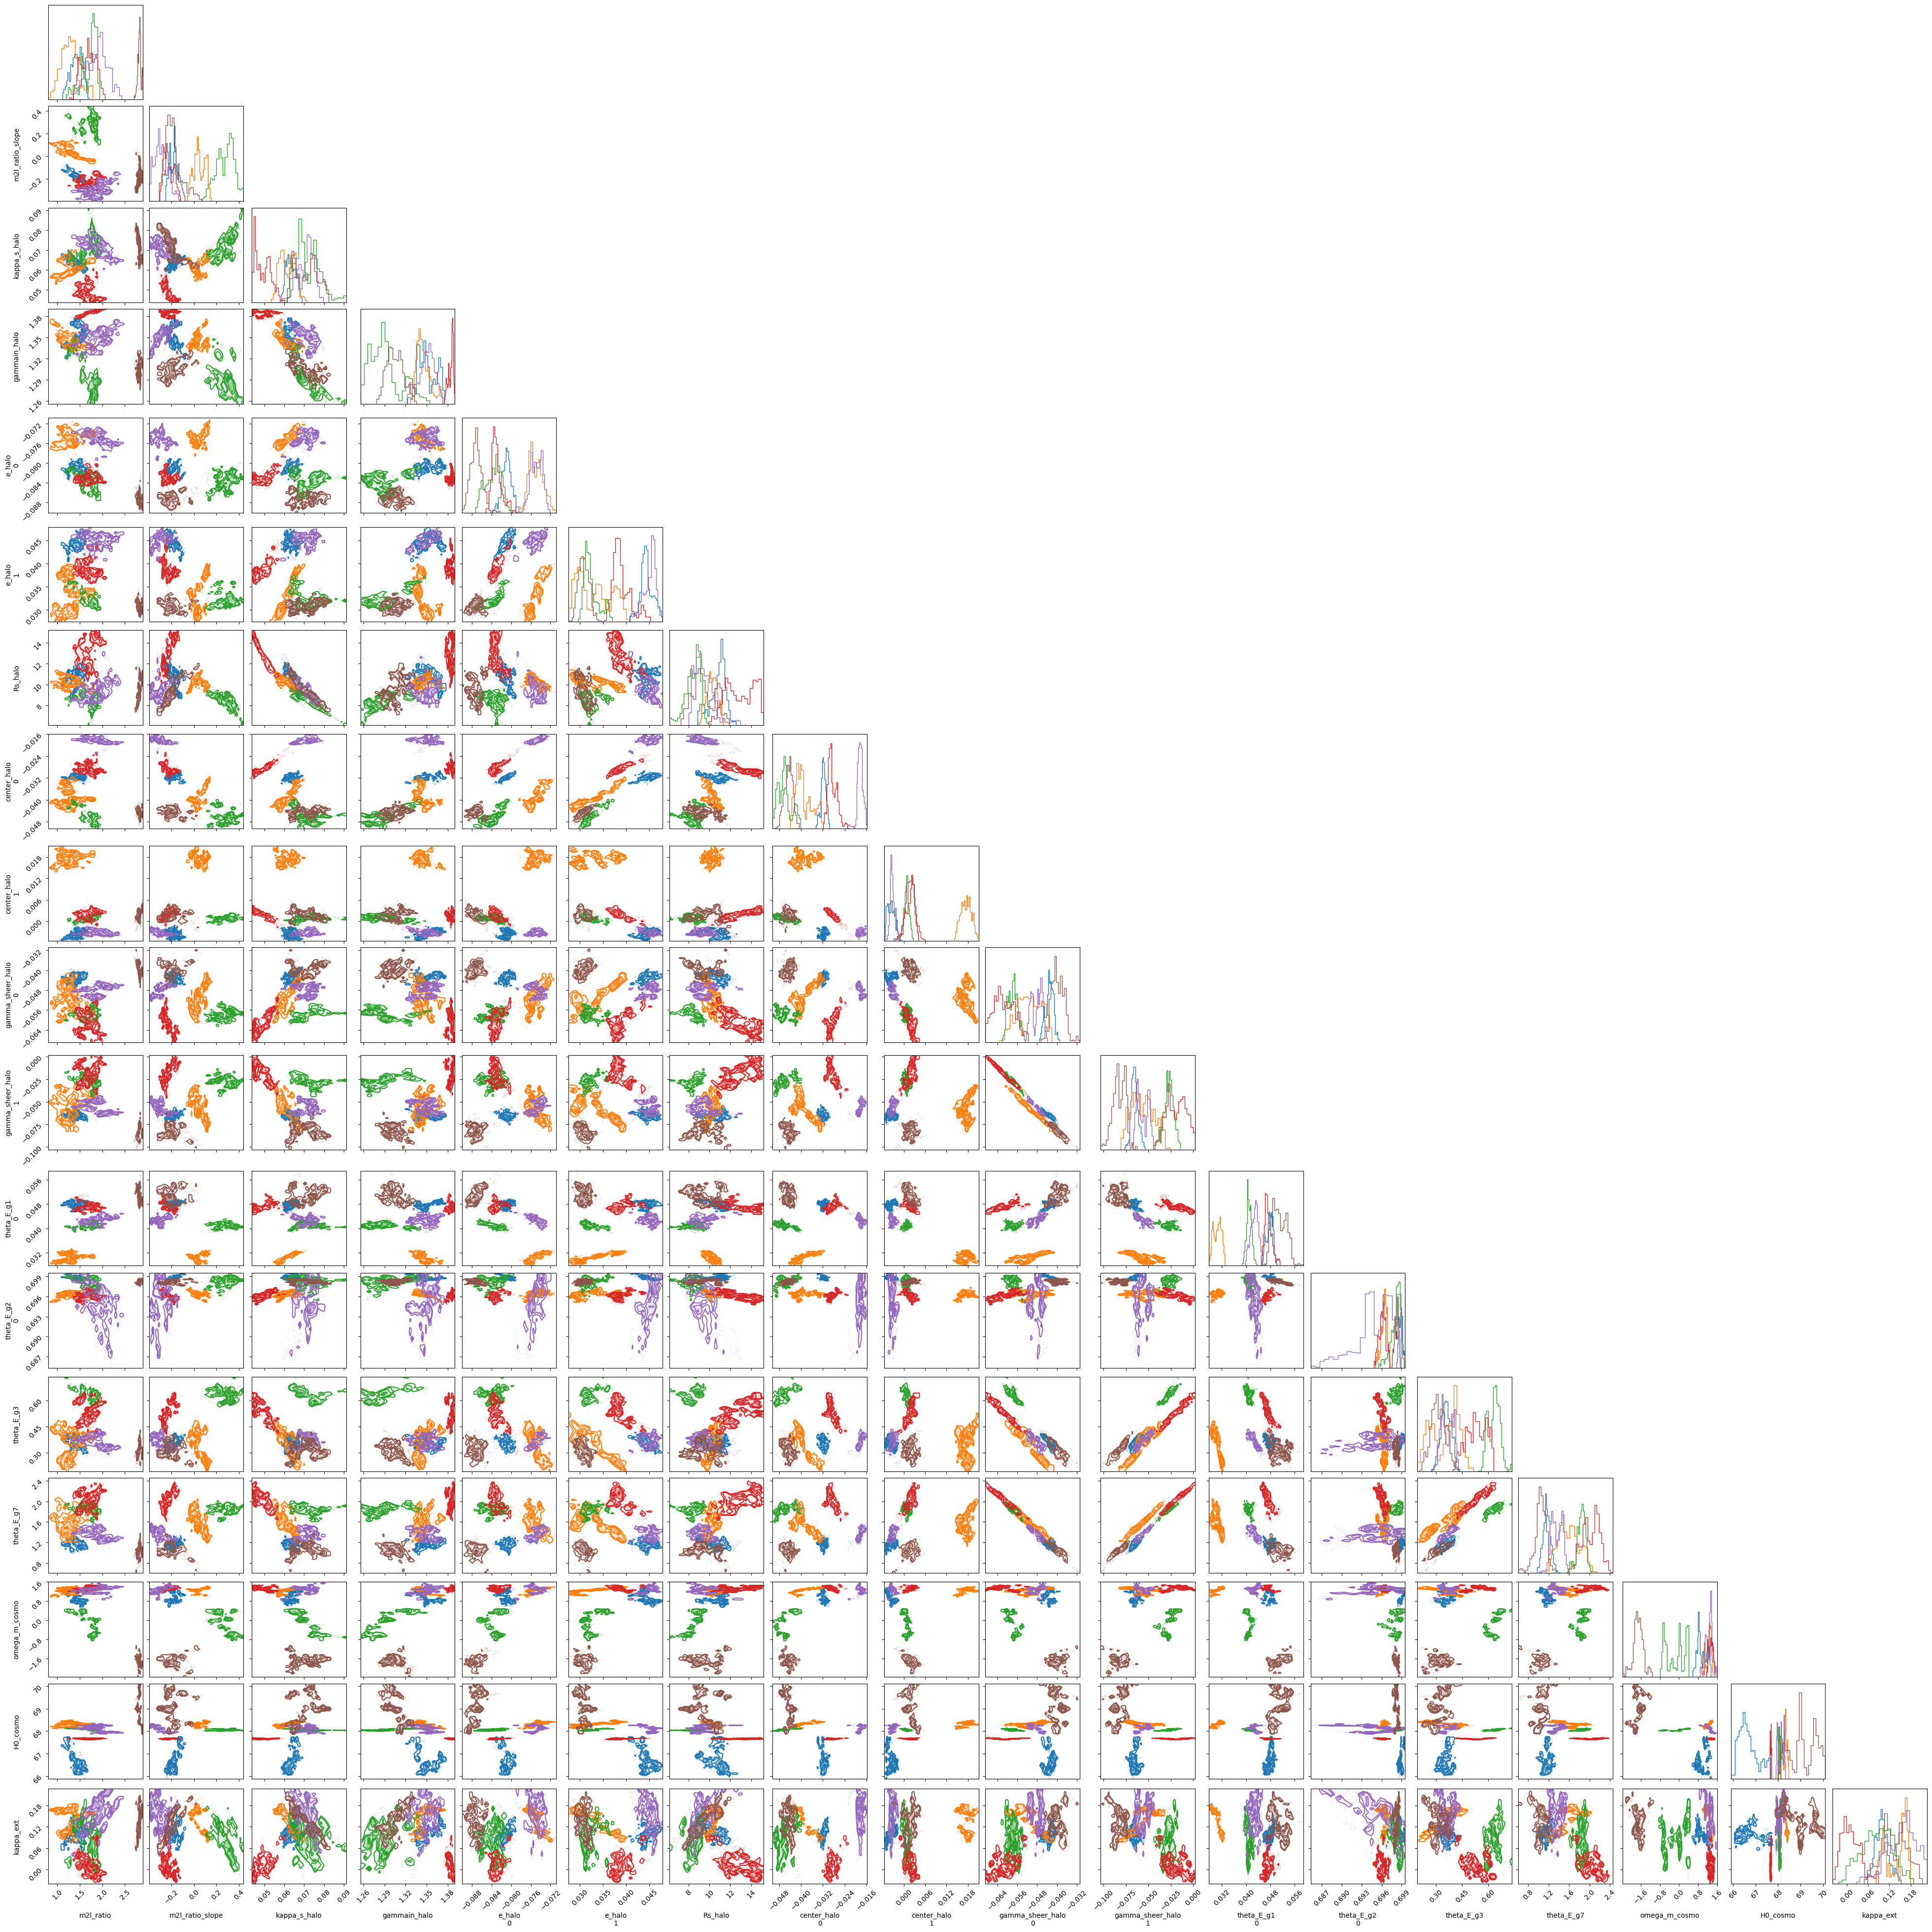

In [7]:
fig_corner = None
for i in range(num_chains):
    fig_corner = corner.corner(
        post.isel(chain=i),
        var_names=corner_vars_main,
        color=f'C{i}',
        fig=fig_corner,
    )
plt.show()


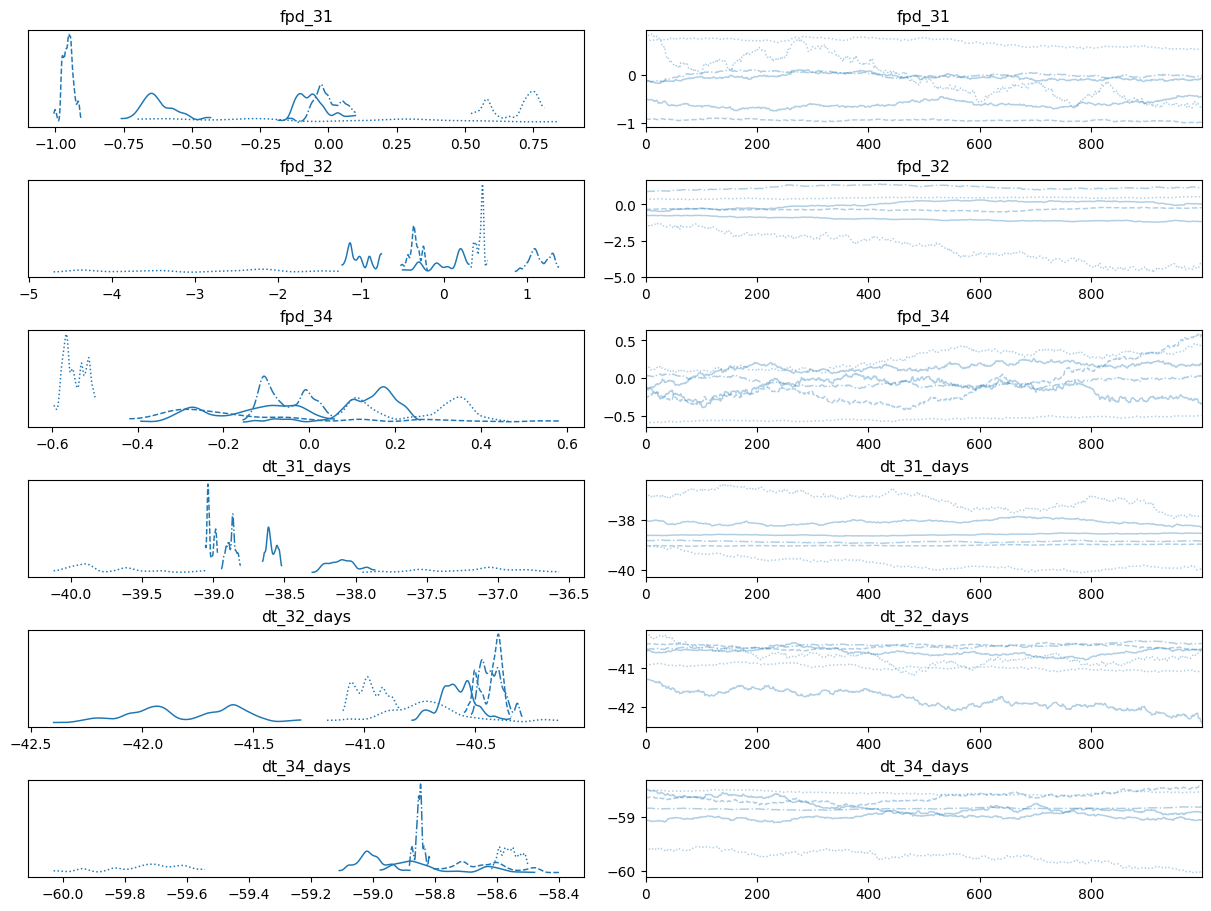

In [8]:
trace_delay_vars = [name for name in vars_delay if name in post.data_vars]
_ = az.plot_trace(
    inf_data_pixel,
    var_names=trace_delay_vars,
    figsize=(12, max(6, 1.5 * len(trace_delay_vars))),
)
plt.show()


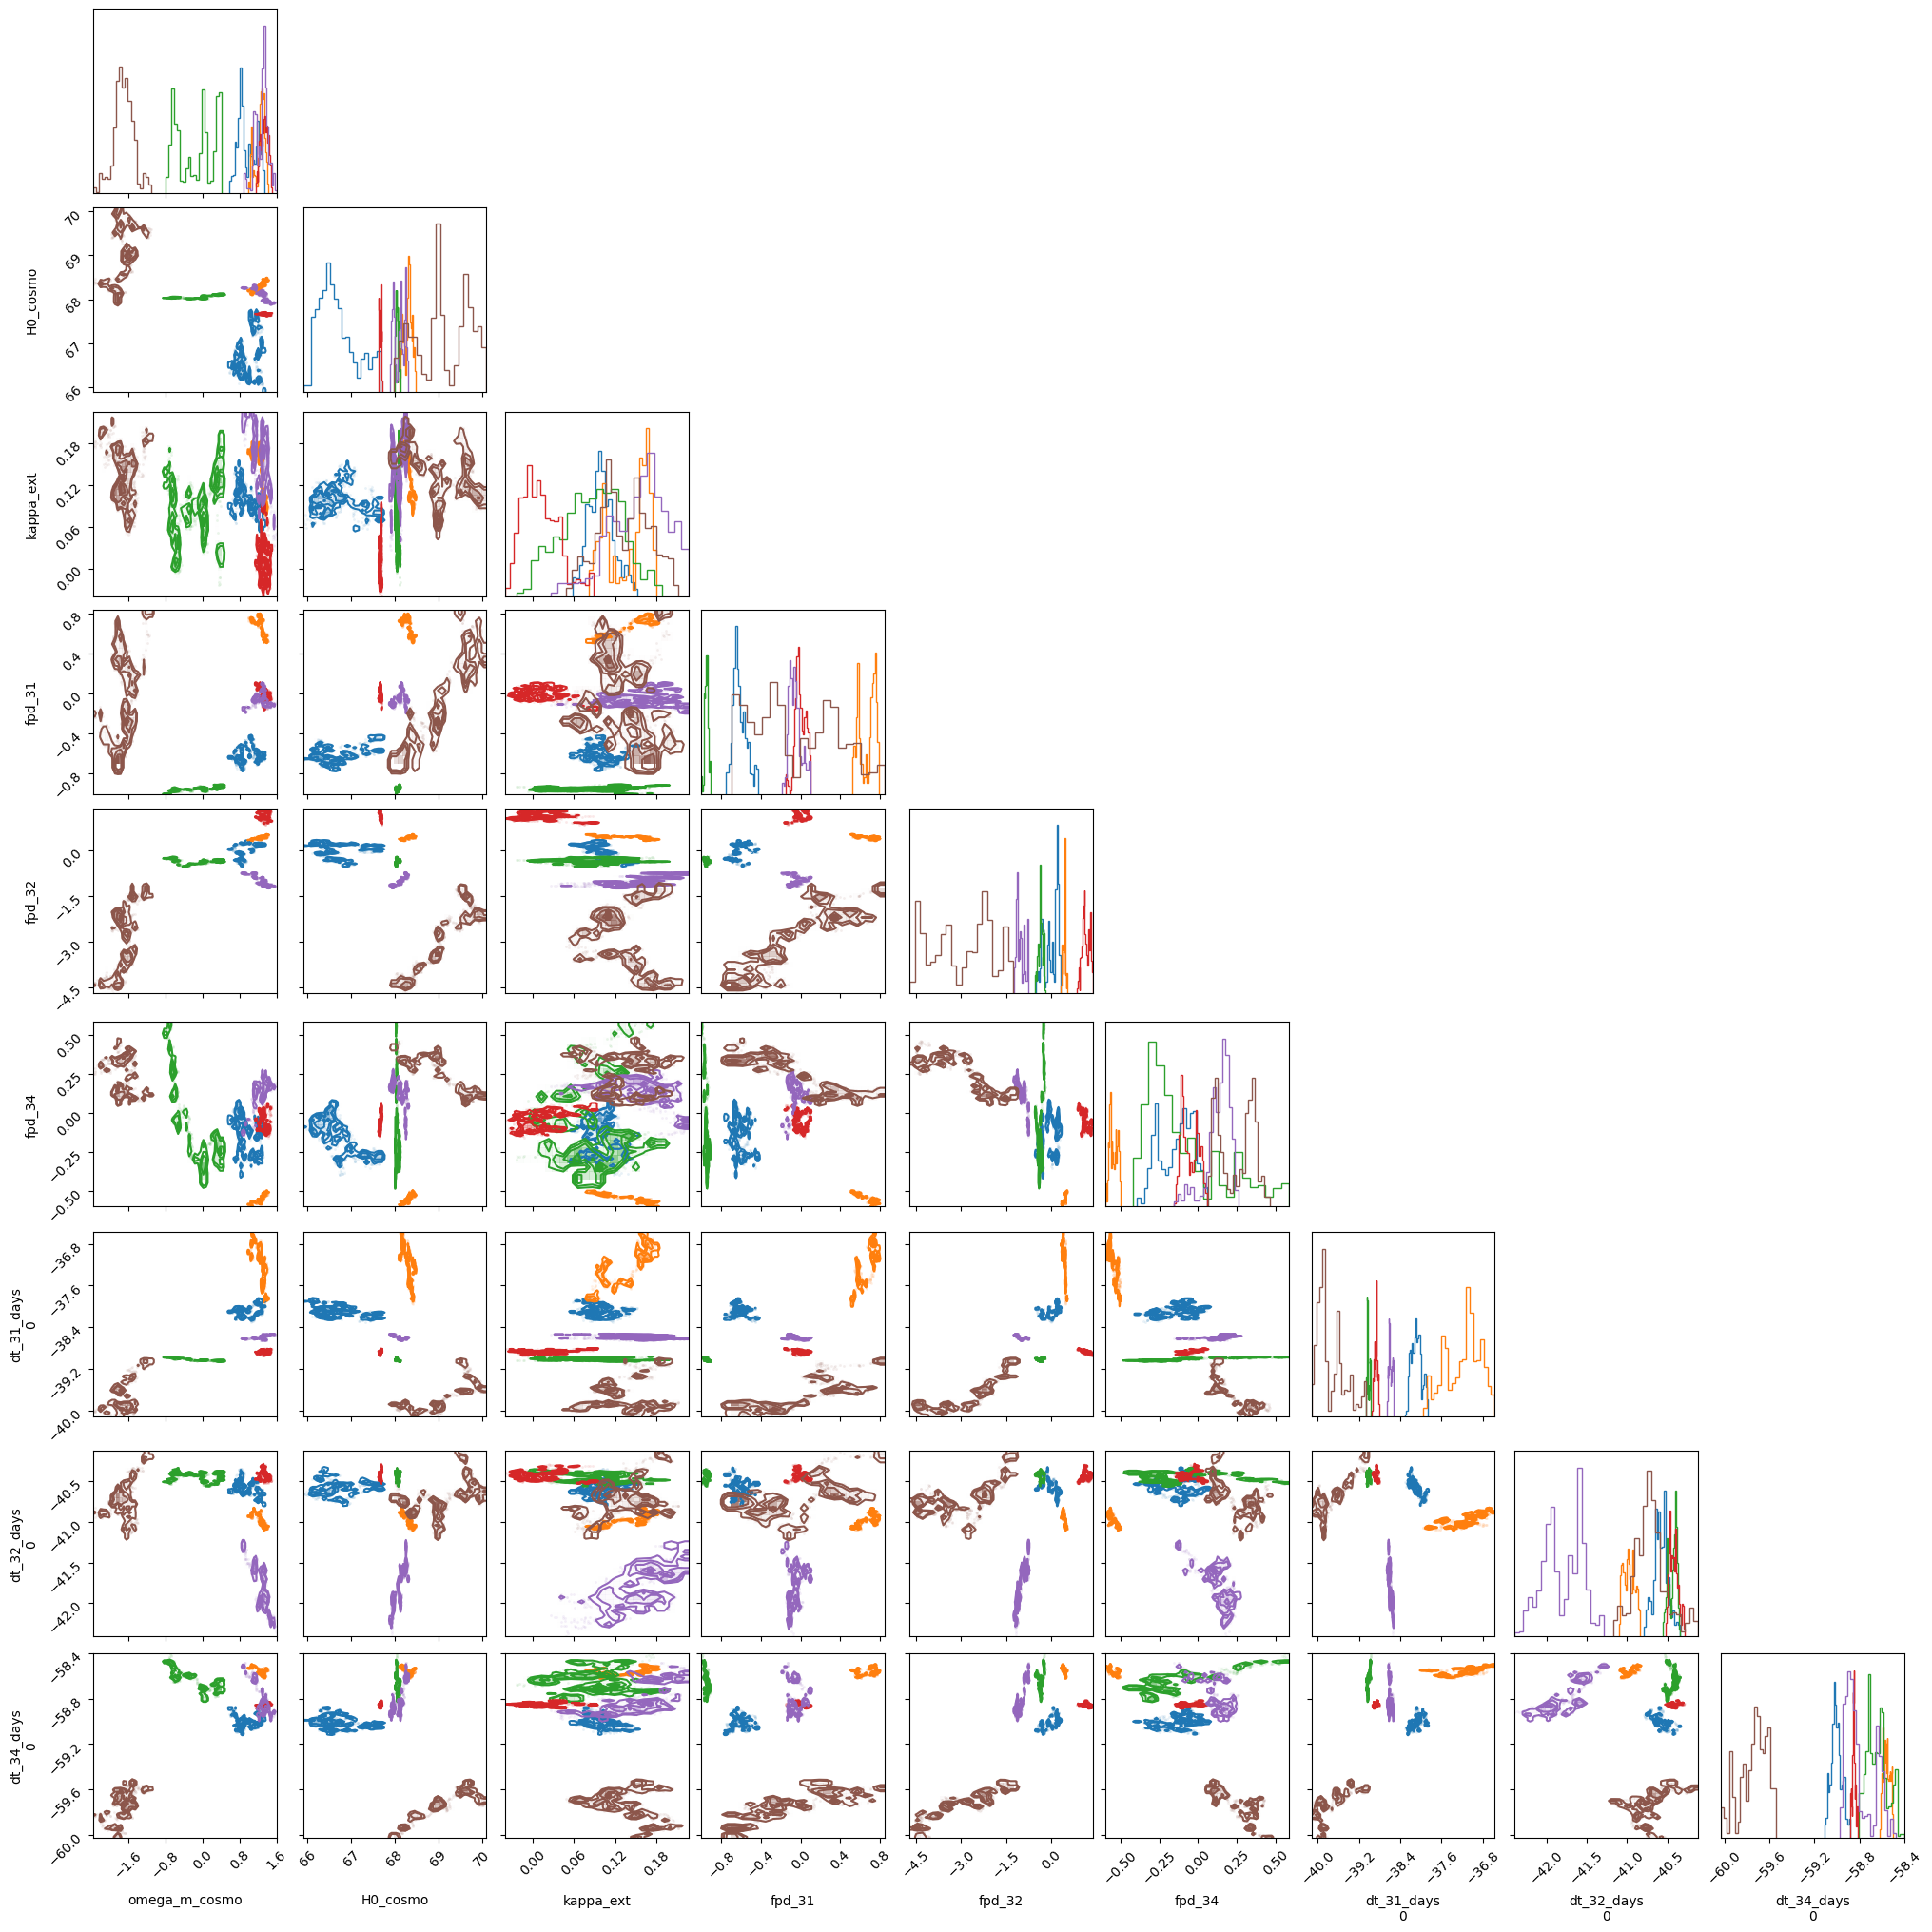

In [9]:
fig_corner = None
for i in range(num_chains):
    fig_corner = corner.corner(
        post.isel(chain=i),
        var_names=corner_vars_delay,
        color=f'C{i}',
        fig=fig_corner,
    )
plt.show()


In [10]:
for name in [n for n in vars_delay if n in post.data_vars]:
    vals = np.asarray(post[name].values, dtype=float)
    print(name, 'median by chain =', np.median(vals, axis=1))


fpd_31 median by chain = [-0.63049282  0.71137571 -0.95315328 -0.00823371 -0.06326385 -0.13579907]
fpd_32 median by chain = [ 0.0559387   0.45101055 -0.35057093  1.13313942 -1.03541436 -2.76659909]
fpd_34 median by chain = [-0.12000726 -0.54935486 -0.18676512 -0.0632928   0.1519681   0.27393759]
dt_31_days median by chain = [[-38.09411727]
 [-37.10402984]
 [-39.02779887]
 [-38.86757593]
 [-38.597908  ]
 [-39.85903493]]
dt_32_days median by chain = [[-40.5846703 ]
 [-40.98067197]
 [-40.41979573]
 [-40.42691419]
 [-41.81007907]
 [-40.72406673]]
dt_34_days median by chain = [[-59.01015703]
 [-58.56001281]
 [-58.64565038]
 [-58.85007512]
 [-58.85127032]
 [-59.71864429]]


In [11]:
summary_vars = [
    name for name in (vars_mass + vars_power + vars_point_source + vars_cosmo + vars_delay)
    if name in post.data_vars
]
az.summary(post, var_names=summary_vars)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m2l_ratio,1.802,0.524,1.176,2.894,0.204,0.138,8.0,25.0,2.23
m2l_ratio_slope,-0.092,0.204,-0.346,0.348,0.080,0.048,7.0,15.0,2.76
kappa_s_halo,0.065,0.009,0.044,0.078,0.003,0.002,8.0,11.0,2.27
gammain_halo,1.338,0.034,1.280,1.390,0.013,0.007,7.0,13.0,3.10
e_halo[0],-0.081,0.005,-0.088,-0.073,0.002,0.001,7.0,20.0,2.78
e_halo[1],0.037,0.006,0.029,0.047,0.002,0.001,7.0,36.0,2.56
Rs_halo,10.205,1.701,7.509,14.252,0.622,0.484,8.0,11.0,2.05
center_halo[0],-0.035,0.010,-0.049,-0.018,0.004,0.002,7.0,20.0,3.23
center_halo[1],0.002,0.007,-0.005,0.018,0.003,0.002,7.0,13.0,2.98
gamma_sheer_halo[0],-0.050,0.008,-0.064,-0.036,0.003,0.001,7.0,11.0,2.99


In [12]:
for i in range(num_chains):
    print(f'chain {i}')
    print(az.summary(post.isel(chain=[i]), var_names=[name for name in vars_cosmo + vars_delay if name in post.data_vars]))


arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


chain 0
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
omega_m_cosmo   0.960  0.196   0.693    1.309      0.176    0.024       1.0   
H0_cosmo       66.673  0.419  66.064   67.523      0.181    0.166       7.0   
kappa_ext       0.099  0.019   0.069    0.141      0.013    0.003       2.0   
fpd_31         -0.617  0.070  -0.756   -0.489      0.033    0.012       5.0   
fpd_32          0.005  0.225  -0.352    0.299      0.193    0.045       2.0   
fpd_34         -0.139  0.107  -0.317    0.026      0.044    0.011       6.0   
dt_31_days[0] -38.090  0.098 -38.247  -37.905      0.039    0.017       7.0   
dt_32_days[0] -40.580  0.085 -40.752  -40.425      0.049    0.016       3.0   
dt_34_days[0] -59.005  0.048 -59.087  -58.914      0.015    0.007      10.0   

               ess_tail  r_hat  
omega_m_cosmo      17.0    NaN  
H0_cosmo           24.0    NaN  
kappa_ext          12.0    NaN  
fpd_31             12.0    NaN  
fpd_32             11.0    NaN  
fpd

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
omega_m_cosmo   1.243  0.102   1.039    1.383      0.086    0.026       1.0   
H0_cosmo       68.302  0.092  68.131   68.449      0.078    0.016       1.0   
kappa_ext       0.139  0.030   0.091    0.178      0.027    0.005       1.0   
fpd_31          0.675  0.083   0.537    0.780      0.074    0.013       1.0   
fpd_32          0.435  0.047   0.342    0.495      0.036    0.008       2.0   
fpd_34         -0.546  0.025  -0.582   -0.502      0.023    0.003       1.0   
dt_31_days[0] -37.188  0.334 -37.854  -36.679      0.286    0.049       1.0   
dt_32_days[0] -40.975  0.068 -41.084  -40.863      0.056    0.010       2.0   
dt_34_days[0] -58.558  0.030 -58.607  -58.506      0.021    0.005       2.0   

               ess_tail  r_hat  
omega_m_cosmo      12.0    NaN  
H0_cosmo           13.0    NaN  
kappa_ext          11.0    NaN  
fpd_31             11.0    NaN  
fpd_32             12.0    NaN  
fpd_34     

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
omega_m_cosmo   1.275  0.137   1.057    1.547      0.096    0.032       2.0   
H0_cosmo       68.103  0.122  67.906   68.276      0.107    0.019       1.0   
kappa_ext       0.154  0.041   0.081    0.224      0.026    0.006       3.0   
fpd_31         -0.055  0.061  -0.145    0.076      0.032    0.012       5.0   
fpd_32         -1.014  0.135  -1.188   -0.758      0.123    0.026       1.0   
fpd_34          0.132  0.079  -0.050    0.247      0.057    0.024       2.0   
dt_31_days[0] -38.591  0.034 -38.646  -38.533      0.029    0.005       2.0   
dt_32_days[0] -41.801  0.237 -42.237  -41.450      0.217    0.032       1.0   
dt_34_days[0] -58.803  0.126 -58.966  -58.588      0.095    0.034       2.0   

               ess_tail  r_hat  
omega_m_cosmo      11.0    NaN  
H0_cosmo           14.0    NaN  
kappa_ext          12.0    NaN  
fpd_31             26.0    NaN  
fpd_32             13.0    NaN  
fpd_34     